### Libraries

In [1]:
!pip install wget
import wget
# wget은 터미널에서 파일 다운로드할 때 많이 쓰이는 도구
# Python용 wget 패키지는 wget.download(url) 형태로 인터넷에서 파일 다운로드할 수 있게 해줘.
# 이건 VOC 데이터셋을 Colab에서 다운로드할 때 자주 써!

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=094432d816208a90bc6e300f1462d3342b2c952f51aec14c6c9878612cf8ffa2
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget


In [2]:
# Python 2/3 호환성을 위해 print와 division 연산 방식을 Python 3 스타일로 강제함
from __future__ import print_function, division

# 파일 경로, 시스템 관련 기능
import os

# PyTorch의 핵심 모듈
import torch

# 수치 연산용 패키지 (가능하면 numpy 최소 사용해야 함!)
import numpy as np

# 랜덤 시드 등 설정에 사용
import random

# 데이터 불러오고 배치 만들 때 사용하는 PyTorch 유틸리티
from torch.utils.data import DataLoader
from torch.utils.data.sampler import Sampler

# torchvision에서 제공하는 VOC 데이터셋 클래스
from torchvision.datasets import VOCDetection

# 압축파일 (예: .tar.gz) 압축 해제에 사용
import tarfile

# 이미지 처리 라이브러리 (scikit-image)
import skimage.io
import skimage.transform
import skimage.color
import skimage

# 이미지 증강/전처리를 위한 torchvision transform 모듈
from torchvision import transforms

# 이미지 열고 다루는 데 사용하는 PIL (Python Imaging Library)
from PIL import Image

# VOC annotation XML 파싱을 위한 XML 모듈
import xml.etree.ElementTree as ET

# PyTorch에서 최적화 도구 (SGD, Adam 등) 가져오기
import torch.optim as optim

# 중복 import — 위에 이미 있음, 나중에 하나만 남기기!
import numpy as np

# 이미지 시각화를 위한 matplotlib
import matplotlib.pyplot as plt

# Tensor → PIL 이미지로 바꿔주는 함수
from torchvision.transforms.functional import to_pil_image

# 이미지에 박스 그릴 때 사용 (PIL 기반)
from PIL import ImageDraw, ImageFont

# 신경망 레이어 정의할 때 사용하는 PyTorch 모듈
import torch.nn as nn

# 또 중복된 import — 위에 이미 있음!
import torch

# 수학 관련 함수들 (ex: sqrt, log 등)
import math

# pretrained model 다운로드용 (잘 안 쓰일 수도 있음)
import torch.utils.model_zoo as model_zoo

# PyTorch에서 제공하는 NMS (Non-Maximum Suppression) 함수
from torchvision.ops import nms


## Load dataset: VOC2007
---
### Complete the following transformation modules
* Normalizer: Implement a Normalizer that normalizes an image using the RGB mean and standard deviation.
* Augmenter: Implement an Augmenter that horizontally flips an image with a 0.5 probability.

**sample['image'] 반환값 구조 3차원 텐서임**






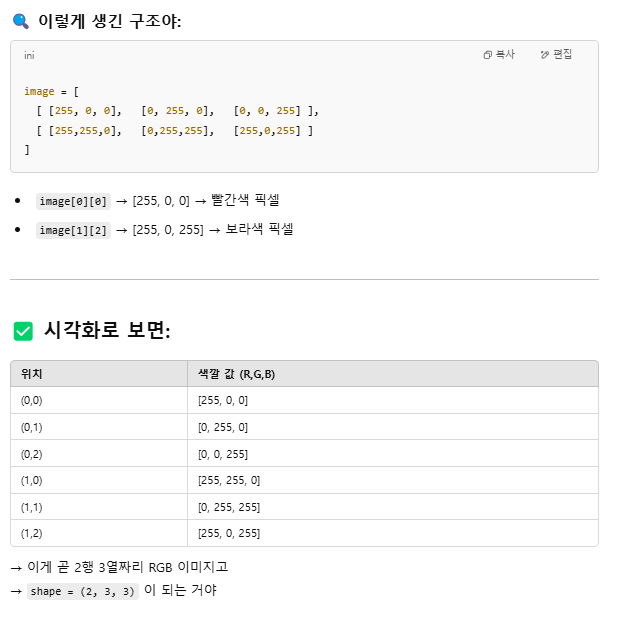

In [3]:
class Resizer(object):
#object는 파이썬에서 모든 클래스가 상속해야 할 기본 클래스(base class) 야.
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, min_side=608, max_side=1024):
#  클래스 안에 def __call__(self, ...) 이 정의되어 있으면,
# 그 클래스 인스턴스를 함수처럼 쓸 수 있어!
#min_side와 max_side는 기본 인자값인데 이건 함수를 호출할 때 그 인자를 생략하면, 미리 지정된 기본값(default value) 가 자동으로 들어가는 거야.



        image, annots = sample['img'], sample['annot']
        # sample은 {'img': 이미지 배열, 'annot': 어노테이션 배열}로 구성된 딕셔너리야
        #딕셔너리는 c++에서 map((string,value)과 같은 개념이고 위처럼 쓰면 img라는 key를 가진 value 배열을 가져온거야
        #어노테이션(annotation)은? 이미지 안에 있는 객체의 정보를 말해 즉 bounding box의 좌표와 그 안의 objects의 이름이 담겨있
# annots =
#[
#   [x1, y1, x2, y2, class_id],  # 첫 번째 객체
#   [x1, y1, x2, y2, class_id],  # 두 번째 객체
#   ...
# ]


######################여기부터 Resize하는 로직#################################
#우리의 목표는 이미지의 가장 짧은 변은 최소한 min_side (608) 보다 커야 하고,
#가장 긴 변은 최대 max_side (1024) 를 넘지 않도록 비율을 유지한 채 resize 하는 것!

        rows, cols, cns = image.shape
        #image 객체가 있고 image.shape는 값이 3개짜리 튜플를 반환함 → (높이, 너비, 채널)


        smallest_side = min(rows, cols)

        # scale = 608/가장 짧은변의 길이 이니까 608이 가장 짧은쪽의 '몇배' 인지가 나옴
        # 이제 이 scale을 사진에 곱할거임 하지만 문제있음 아래서 해결

        scale = min_side / smallest_side

        # check if the largest side is now greater than max_side, which can happen
        # when images have a large aspect ratio
        # 문제 발생 가장 긴쪽이 scale만큼 곱했는데 1024를 넘어버릴수도 그럼 너무 사진이 커짐 scale을 적당히 조절할거

        largest_side = max(rows, cols)

        if largest_side * scale > max_side:
            scale = max_side / largest_side
            #scale에 가장 긴 변을 곱했는데 1024를 넘으면 적당한 값으로 다시 스케일 조정



        # resize the image with the computed scale
        image = skimage.transform.resize(image, (int(round(rows*scale)), int(round((cols*scale)))))
        #round(x) : 숫자를 반올림
        rows, cols, cns = image.shape
        #image.shape는 튜플

        pad_w = 32 - rows%32
        pad_h = 32 - cols%32
        #PyTorch는 입력 이미지 크기가 32의 배수여야 잘 동작해.

        new_image = np.zeros((rows + pad_w, cols + pad_h, cns)).astype(np.float32)
        #np.zeros(shape) : 전부 0으로 채워진 배열 생성
        #배열은 3차원이며 각각 크기를 가짐 (rows + pad_w, cols + pad_h, cns)
        #.astype(np.float32) : float32 형으로 강제변환 (PyTorch가 이걸 좋아해)



        new_image[:rows, :cols, :] = image.astype(np.float32)
        #슬라이싱 문법 = 0부터 rows까지에 image의 첫번째 배열인 rows를 넣는다
        #:0부터 cols까지에 image의 두번째 배열인 cols를 넣는다
        # : → 모든 채널 (RGB 전부) 를 넣는다
        #즉 new_image의 왼쪽 위에 scaling 한 image를 복사해서 넣는다

        ###################여기까지한거######################
        # scale을 곱해서 이미지를 리사이즈함 → image에 저장
        # 0으로 가득 찬 새로운 큰 배열인 new_image를 만들었고
        # 그 new_image의 왼쪽 위에 리사이즈한 image를 붙여 넣었어


        #왜 이렇게 해? 딥러닝 모델에 넣을 때, 이미지 크기를 32로 나누어떨어지게 만들기 위해서야!

        annots = torch.tensor(annots, dtype=torch.float32)
        annots[:, :4] *= scale
        # 리사이즈된 이미지 크기에 맞춰서,
        # bounding box 좌표도 똑같이 scale 비율만큼 곱해주는 것이야!

        #이중 슬라이싱:
        # : → 모든 행 (즉, 모든 박스)
        # :4 → 각 행에서 처음 4개 열 → x1, y1, x2, y2 좌표만 가져오기


        return {
    'img': torch.from_numpy(new_image),
    'annot': annots,
    'scale': scale
}
        # torch.from_numpy(...)은 numpy 배열을 PyTorch 텐서(tensor)로 바꿔주는 함수야.
         #return { '키': 값, '키2': 값2, ... } 은 파이썬의 딕셔너리(dictionary) 생성 문법이야


class Augmenter(object):
    def __call__(self, sample, flip_x=0.5):
        #################################
        # TODO: complete this module. #
        #################################
        # Augmenter is a module that augments the training set.
        # Implement and use an Augmentor that includes at least horizontal flipping with probability 0.5
        # as part of the augmentation process.

         # [START]

         # 1. sample에서 이미지와 바운딩 박스 꺼내기
        image, annots = sample['img'], sample['annot']

        # 2. 랜덤 0~1 값이 flip_x보다 작을 때 실행됨
        if torch.rand(1).item() < flip_x:
        #torch.rand(n)은 "0~1 사이의 랜덤 실수(float)를 n개 생성해라" 는 뜻. 근데 이때 생성한 실수는 tensor 자료형임
        #그래서 그 텐서를 float형으로 꺼내주는게 .item함수

        # 3. 이미지 세로 그대로, 가로 방향만 역순, 채널은 그대로 뒤집기
          image = image[:, ::-1, :]
        #슬라이싱 개념 심화학습 start 생략 시, step이 양수면 0부터, step이 음수면 "마지막 인덱스"부터 시작한다!
        #이거보고 공부 : https://twpower.github.io/119-python-list-slicing-examples

        # 4. 바운딩 박스도 좌우 뒤집히게 좌표 보정

        #시작전 annots.shape = (N, 5)의 반환값 부터 파악!
        #박스 N개가 있고, 각 박스마다
        #[x1, y1, x2, y2, class_id] 5개의 정보가 들어 있다는 뜻이야!


        # 이미지 너비 정보 필요
          width = image.shape[1]
          annots = torch.tensor(annots, dtype=torch.float32)
          if annots.shape[0] > 0:
            for i in range(annots.shape[0]):
          # 각 박스의 왼쪽(x1), 오른쪽(x2) 좌표 가져오기
              x1 = annots[i][0].item()
              x2 = annots[i][2].item()

        # 좌우 반전된 좌표 계산
              leftmost = width - x2
              rightmost = width - x1

        # 다시 대입
              annots[i][0] = leftmost
              annots[i][2] = rightmost

        # 5. 다시 sample 형태로 반환
        return {'img': image, 'annot': annots}

        # [END]


class Normalizer(object):
    # 이미지를 모델에 넣기 전에, 픽셀 값을 평균 0, 표준편차 1 기준으로 스케일 조정해주는 거야. 원래는 0부터 255안인데 이걸 정규화 해야 모델이 학습하기 편해짐

    def __init__(self):
      #__init__ : 파이썬에서는 __init__이 생성자다!
      #self: self는 "그 객체 자기 자신"을 의미 파이썬은 명시적으로 self를 함수의 첫 번째 인자로 넣어줘야 한다. 역할은 this키워드와 완전히 같지만 C++/Java처럼 숨겨진 this를 자동으로 제공해주지 않는다.


        self.mean = np.array([[[0.485, 0.456, 0.406]]])
        self.std = np.array([[[0.229, 0.224, 0.225]]])
        #값은 ImageNet 데이터셋 기준 R 평균: 0.485, G 평균: 0.456, B 평균: 0.406 R 표준편차: 0.229, G: 0.224, B: 0.225로 정해져있고 그걸쓰는것
        #3차원 텐서로 설정한 이유는 브로드캐스팅(나중에 실제 이미지랑 이 self.mean이랑 연산하면 self.mean이 나머지 차원은 [0.485,0.456,0.406]을 복사해 차원을 채워 연산해주는 것)

    def __call__(self, sample):
      #__call__()은 파이썬 클래스에서 "이 객체를 함수처럼 호출할 수 있게 해주는" 특별한 함수야! 이걸 파이썬에서는 매직 메서드라고 불러!


        #################################
        # TODO: complete this module. #
        #################################
        # Implement a Normalizer that normalizes an image using the RGB mean and standard deviation.

        # [START]

        #1.이미지와 박스 샘플에서 가져오기
        image, annots = sample['img'], sample['annot']

        #2.정규화 방식은 여러개가 있지만 평균과 표준편차를 이용해 정규화하는 방식은 이공식을 사용 (여기서 브로드캐스팅을 사용)
        image = (image - self.mean) / self.std

        #3.다시 딕셔너리 형태로 반환
        return {'img': image, 'annot': annots}

        # [END]


class UnNormalizer(object):

    def __init__(self, mean=None, std=None):

        if mean == None:
            self.mean = [0.485, 0.456, 0.406]
        else:
            self.mean = mean
        if std == None:
            self.std = [0.229, 0.224, 0.225]
        else:
            self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # zip()은 여러 개의 리스트(또는 튜플 등)를 같은 인덱스끼리 묶어주는 함수야!
        return tensor

## VOC Dataset
---
Automatically download and use the VOC2007 dataset if it is not available.    
Complete the VOCDataset class.

VOC2007 = 객체 탐지(Object Detection) 과제에서 자주 쓰는 공개 이미지/어노테이션 데이터셋



In [4]:
#VOC를 다운받기위해 교수가 만들어놓은 함수 그냥 쓰면 됌
def VOC_download(root_dir, year="2007"):
    if os.path.exists(os.path.join(root_dir, 'VOCdevkit')):
        print("VOC exists.")
        return

    urls = {
        "2007": {
            "trainval": "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar",
            "test": "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar"
        },
    }

    if year not in urls:
        raise ValueError("Only VOC 2007 and 2012 are supported")

    trainval_download_path = os.path.join(root_dir, f"VOC{year}.tar")

    print(f"Downloading VOC {year} train/val data...")
    wget.download(urls[year]["trainval"], trainval_download_path)

    with tarfile.open(trainval_download_path, "r") as tar:
        tar.extractall(root_dir)

    os.remove(trainval_download_path)

    if year == "2007":
        test_download_path = os.path.join(root_dir, f"VOC{year}_test.tar")
        print(f"\nDownloading VOC {year} test data...")
        wget.download(urls[year]["test"], test_download_path)

        with tarfile.open(test_download_path, "r") as tar:
            tar.extractall(root_dir)

        os.remove(test_download_path)

#VOC"VOC2007 데이터셋 경로 설정하고, 필요하면 다운로드하고, train/val/test 구분해서 파일 목록 가져오고, 이미지 전처리(transform)까지 셋업하는 클래스!"
class VOCDataset(VOCDetection):
    def __init__(self, root_dir, year="2007", image_set="trainval", transform=False, download=True):
        self.root_dir = root_dir
        self.year = year
        self.image_set = image_set

        if download:
            VOC_download(root_dir=self.root_dir, year=self.year)

        if transform:
            if image_set == 'trainval':
                self.transform = transforms.Compose([Normalizer(), Augmenter(), Resizer()])
            elif image_set == 'test':
                self.transform = transforms.Compose([Normalizer(), Resizer()])

        imageset_file = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "ImageSets", "Main", image_set + ".txt")
        #"VOC2007 데이터셋 경로 설정하고, 필요하면 다운로드하고,train/val/test 구분해서 파일 목록 가져오고,이미지 전처리(transform)까지 셋업하는 코드!"

        ############################################################################
        # TODO: assign appropriate values to 'self.image_ids' and 'self.classes'   #
        ############################################################################
        # self.image_ids: A list containing image names as elements.
        # self.classes: Class names defined in the order they exist in the VOC dataset.
        # [START]

        # 어떤 파일을 읽어야 할지 알려주는 게 바로 image_ids
        # 1. 텍스트 파일 열어서 각 줄에 있는 이미지 ID만 리스트로 저장
        with open(imageset_file, "r") as f:
          self.image_ids = [line.strip() for line in f.readlines()]



        # 2. VOC에 나오는 클래스 20개를 직접 적어주기
        self.classes = [
        "aeroplane", "bicycle", "bird", "boat", "bottle",
        "bus", "car", "cat", "chair", "cow", "diningtable",
        "dog", "horse", "motorbike", "person", "pottedplant",
        "sheep", "sofa", "train", "tvmonitor"]

        # 3. class에 인덱스 달아주기
        self.class_to_ind = dict(zip(self.classes, range(len(self.classes))))

# self.classes = ["cat", "dog", "car"]에서 3번 코드 실행하면
#         self.class_to_ind = {
#     "cat": 0,
#     "dog": 1,
#     "car": 2
# }
# 이렇게 됌!
        # [END]


        #잘 나오나 찍어보는 코드
        #print(self.image_ids)


    def num_classes(self):
        return len(self.classes)


    def __len__(self):
        return len(self.image_ids)


    def __getitem__(self, idx):

        # 1. 현재 index 번째 이미지 ID 가져오기
        image_id = self.image_ids[idx]

        # 2. 이미지 파일 경로 만들기
        image_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "JPEGImages", image_id + ".jpg")

        # 3. 이미지 열기 (PIL로) → RGB로 강제 변환
        img = Image.open(image_path).convert("RGB")

        # 4. PIL 이미지를 numpy 배열로 변환 + 실수형(float32)로 바꾸고 → 0~1로 정규화
        img = np.array(img).astype(np.float32) / 255.0

        # 5. 어노테이션(xml) 경로 만들기
        annotation_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "Annotations", image_id + ".xml")

        #6.XML 전체 구조에 접근할 수 있는 트리를 만들것
        #.parse(path)는 XML 파일을 읽고 → 트리(tree) 구조 객체로 변환
        tree = ET.parse(annotation_path)

        #7.tree.getroot() : XML의 최상단 엘리먼트(= <annotation> 태그)를 가져오는 함수야.루트 노드를 기준으로 그 밑에 있는 태그들에 접근할 수 있어.
        root = tree.getroot()

        annots = []
        #################################################
        # TODO: assign appropriate values to 'annots'   #
        #################################################
        # [START]# <object> 태그 하나당 객체 하나
        for obj in root.findall("object"):
            # 클래스 이름 꺼내기 (예: 'dog')
            name = obj.find("name").text

            # 클래스 이름을 숫자 인덱스로 변환 (예: 'dog' → 12)
            class_idx = self.class_to_ind[name]

            # 바운딩 박스 좌표 정보 꺼내기
            bndbox = obj.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)

            # 하나의 객체 정보를 리스트로 저장
            annots.append([xmin, ymin, xmax, ymax, class_idx])


        # [END]

        sample = {'img': img, 'annot': annots}
        if self.transform:
            sample = self.transform(sample)
        return sample


    def image_aspect_ratio(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.root_dir, "VOCdevkit", "VOC"+self.year, "JPEGImages", image_id + ".jpg")
        img = Image.open(image_path)
        return float(img.width) / float(img.height)


class AspectRatioBasedSampler(Sampler):
    def __init__(self, data_source, batch_size, drop_last):
        self.data_source = data_source
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.groups = self.group_images()

    def __iter__(self):
        random.shuffle(self.groups)
        for group in self.groups:
            yield group

    def __len__(self):
        if self.drop_last:
            return len(self.data_source) // self.batch_size
        else:
            return (len(self.data_source) + self.batch_size - 1) // self.batch_size

    def group_images(self):
        # determine the order of the images
        order = list(range(len(self.data_source)))
        order.sort(key=lambda x: self.data_source.image_aspect_ratio(x))

        # divide into groups, one group = one batch
        return [[order[x % len(order)] for x in range(i, i + self.batch_size)] for i in range(0, len(order), self.batch_size)]

In [5]:
path2data = '/content/VOC'
if not os.path.exists(path2data):
    os.mkdir(path2data)

In [6]:
dataset_train = VOCDataset(root_dir=path2data, year="2007", image_set="trainval", transform=True)
dataset_val = VOCDataset(root_dir=path2data, year="2007", image_set="test", transform=True)


VOC exists.


## Visualization
---
Let's examine how the ground truth data is structured.


이건 VOC 데이터셋에서 1장의 이미지 + 바운딩 박스(annotation) 를 시각화하는 코드야.
딱 너의 과제에서 “제대로 어노테이션 잘 불러오고 있는지 확인하라”는 파트지!


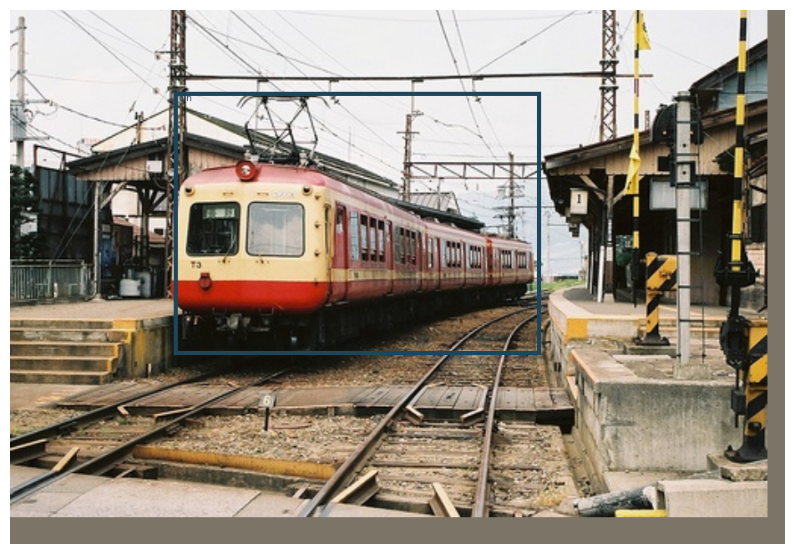

In [7]:
##########################
# TODO: get 'classes'    #
##########################
# [START]

classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]


# [END]

colors = np.random.randint(0, 255, size=(len(classes), 3), dtype='uint8')

def show_sample(sample, classes=classes, colors=colors, GT=True, model=None):
    # permute (H, W, C) => (C, H, W)
    img = sample['img']
    img = img.permute(2, 0, 1) # (C, H, W)

    unorm = UnNormalizer()
    img = unorm(img.clone())
    img = torch.clamp(img, 0, 1)

    pil_img = to_pil_image(img)
    draw = ImageDraw.Draw(pil_img)

    if GT:
        annot = sample['annot']
        if torch.is_tensor(annot):
            annot = annot.cpu().numpy()

        for box in annot:
            if box[0] < 0:
                continue
            x1, y1, x2, y2, cls_idx = box
            cls_idx = int(cls_idx)
            color = tuple(int(c) for c in colors[cls_idx])
            label = classes[cls_idx]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=5)
            draw.text((x1, y1), label, fill=color)
            # font = ImageFont.truetype("arial.ttf", 20)
            # draw.text((x1, y1), label, fill=color, font=font)
    else:
        with torch.no_grad():
            model.eval()
            finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates = model(img.unsqueeze(0).cuda().float())
            finalScores = finalScores.cpu()
            finalAnchorBoxesIndexes = finalAnchorBoxesIndexes.cpu()
            finalAnchorBoxesCoordinates = finalAnchorBoxesCoordinates.cpu()

            for score, cls_idx, box in zip(finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates):
                x1, y1, x2, y2 = box.int().tolist()
                cls_idx = int(cls_idx)
                color = tuple(int(c) for c in colors[cls_idx])
                label = classes[cls_idx]
                draw.rectangle([x1, y1, x2, y2], outline=color, width=5)
                draw.text((x1, y1), f'{label}-{score}', fill=color)

    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(pil_img))
    plt.axis('off')
    plt.show()

sample = dataset_val[123]
#내부적으로는 이게 실행됌 -> sample = dataset_val.__getitem__(123)
show_sample(sample)

<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)


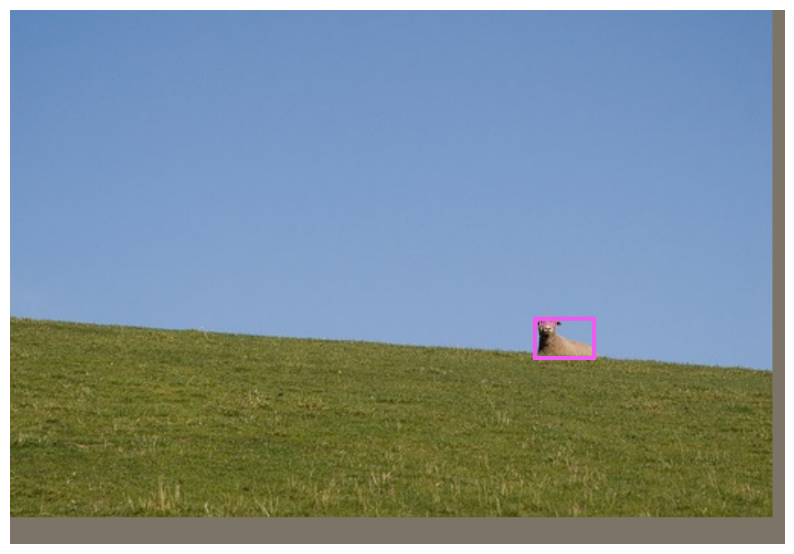

In [8]:
sample = dataset_train[123]
#내부적으로는 이게 실행됌 -> sample = dataset_val.__getitem__(123)
show_sample(sample)

#사진 뒤집힐떄 <ipython-input-33-47cc876160d9>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).annots = torch.tensor(annots, dtype=torch.float32)
#경고가 있음 근데 이건 위에서 사진 뒤집는 augmenter코드에서 리스트형태로 annots를 받아왔기 때문에 .shape를 못쓰는 문제가 있었고
#그 shape를 스려면 넘파이 아님 텐서인데 과제에서 파이토치 쓰라해서 텐서쓴

### Dataloaders & collater function
---
The VOC dataset comprises samples containing images of various sizes and a variable number of bounding boxes. We process this dataset in batches, and to handle samples with different formats, we implement and utilize a collater function. For more details, refer to the [official PyTorch documentation](https://pytorch.org/docs/stable/data.html#loading-batched-and-non-batched-data).

"VOC 데이터셋은 이미지마다 크기도 다르고,
들어 있는 객체 수도 다르기 때문에
이런 '불규칙한 데이터'를 배치로 묶어 처리하려면
collater라는 걸 직접 구현해서 DataLoader랑 같이 써야 해요."

In [9]:
def collater(data):
# data: DataLoader가 batch_size만큼 뽑은 sample 리스트 → 예: [sample1, sample2, sample3, sample4]
# 각 sample은 {img, annot, scale} 딕셔너리 구조

    imgs = [s['img'] for s in data]
    annots = [s['annot'] for s in data]
    scales = [s['scale'] for s in data]
    #for s in data는 list comprehension 문법
    #각 sample 딕셔너리에서 img, annot, scale 추출해서 리스트로 모음
###################liset comprehension################################
# data = [
#     {
#         'img': torch.rand(300, 400, 3),     # 300×400 RGB 이미지
#         'annot': torch.tensor([[50, 60, 150, 180, 14]]),
#         'scale': 0.82
#     },
#     {
#         'img': torch.rand(500, 600, 3),     # 500×600 RGB 이미지
#         'annot': torch.tensor([[100, 120, 300, 350, 7]]),
#         'scale': 0.95
#     }
# ]

# imgs = [s['img'] for s in data] 하면?
# [
#     torch.Size([300, 400, 3]),
#     torch.Size([500, 600, 3])
# ]
#########################################################################

    widths = [int(s.shape[0]) for s in imgs]
    heights = [int(s.shape[1]) for s in imgs]
    batch_size = len(imgs)

    #s.shape[0] → 이미지의 세로 (높이)
    #s.shape[1] → 이미지의 가로 (너비)
    #batch_size → 배치에 들어온 이미지 개수

####################list comprehension####################
# 기존 리스트에서 새로운 리스트를 한 줄로 만드는 파이썬 문법이야!

# imgs = [
#     torch.rand(300, 400, 3),   # 세로 300, 가로 400
#     torch.rand(500, 600, 3)    # 세로 500, 가로 600
# ]

#imgs = [s['img'] for s in data] 하면?
# widths = [s.shape[1] for s in imgs]   # [400, 600]
# heights = [s.shape[0] for s in imgs]  # [300, 500]

#############################################################


    max_width = np.array(widths).max()
    max_height = np.array(heights).max()

    #각 이미지 크기 중에서 가장 큰 세로/가로를 구함 → 패딩 기준 크기로 삼기 위해
    #**패딩(padding)**이란? 크기가 다른 이미지들을 같은 크기로 맞추기 위해 빈 공간을 0 등으로 채워서 모양을 통일하는 것

    padded_imgs = torch.zeros(batch_size, max_width, max_height, 3)
    #빈 팔렛트 하나 만들고 (크기는 최대 width, height 다 0으로 채우기)

    for i in range(batch_size):
        img = imgs[i]
        padded_imgs[i, :int(img.shape[0]), :int(img.shape[1]), :] = img
        # 이미지 하나씩 꺼내서 → padded_imgs에 좌상단에 복사 (위에서 scale했던 그 코드)
        # 남은 공간은 0 (padding)


        #여기까지가 이미지 배치 통일이었고 이제 박스 배치 통일 할거
        #1. 제일 큰 annot 크기 찾기
    max_num_annots = max(annot.shape[0] for annot in annots)
    #annot.shape는 (box의 갯수, 5(x1x2y1y2객체이름))임


    if max_num_annots > 0:

        annot_padded = torch.ones((len(annots), max_num_annots, 5)) * -1
        # torch.ones((A, B, C)) → A×B×C 크기의 텐서를 1로 채움
        # 0 (axis 0)	배치 인덱스 (몇 번째 이미지인지)
        # 1 (axis 1)	각 이미지 안의 박스 인덱스
        # 2 (axis 2)	박스 정보 [x1, y1, x2, y2, class_idx]
        # -1 → 없는 부분은 -1로 패딩

        # 2.이제 box 복사할거임
        if max_num_annots > 0:


            for idx, annot in enumerate(annots):
                if annot.shape[0] > 0:
                    annot_padded[idx, :annot.shape[0], :] = annot
                    # enumerate(annots)는 인덱스랑 annotation 둘 다 꺼내줌 → 예: idx = 0, annot = img1의 바운딩 박스
                    # annot.shape[0]는 바운딩 박스 개수
                    ###################annot 모양 복습#########################
                    # annot = torch.tensor([
                    #        [50,  60, 150, 180, 14],   # 사람
                    #        [30, 100,  80, 150,  7],   # 고양이
                    #    ])
                   ###########################################################
    else:
        annot_padded = torch.ones((len(annots), 1, 5)) * -1
# 만약 batch에 있는 모든 이미지가 바운딩 박스가 아예 없을 경우 (max_num_annots == 0)
# 그래도 shape 맞추려고 (batch_size, 1, 5) 짜리 dummy를 만들고 전부 -1로 채워둠 (없음을 의미)

    padded_imgs = padded_imgs.permute(0, 3, 1, 2)
    #지금 우리가 짠 padded_imgs는 (배치크기,높이,너비,채널)순임 하지만 PyTorch의 Conv2D, 모델 등은 이렇게 생긴 이미지를 원해
    #(B, C, H, W) ← 채널이 맨 앞으로 와야 함 이코드를 실행하면 그게

    #################################################
    # TODO: complete return                         #
    #################################################
    # [START]

    return {
    'img': padded_imgs,
    'annot': annot_padded,
    'scale': scales }
    # [END]

이제 위에서 작성한 collater 함수를 직접 사용하볼거

이 코드는 VOC 데이터셋을 학습(train)과 검증(val)에 사용할 수 있게
batch 단위로 자동 공급하는 Dataloader를 완성하는 거야!

In [22]:
# Adjust the batch size to suit your GPU environment.
# Select the largest possible batch size that your GPU memory allows. The choice is yours.
BATCH_SIZE = 2

#########################################################################
# TODO: Initialize dataloader_train and dataloader_val with collater()  #
#########################################################################
# [START]

sampler = AspectRatioBasedSampler(dataset_train, batch_size=BATCH_SIZE, drop_last=False)
#AspectRatioBasedSampler: VOC 이미지들은 비율이 제각각이라서
#그냥 무작정 batch로 묶으면 낭비도 생기고, 패딩도 커짐
#그래서 비슷한 비율끼리 묶어주는 샘플러로 batch를 잘 나눠줘


# Train DataLoader
dataloader_train = DataLoader(
    dataset_train,
    batch_sampler=sampler,              # 우리가 만든 AspectRatioBasedSampler 사용
    num_workers=2,                      # 병렬 데이터 로딩 (코랩에서는 2~4 추천)
    pin_memory=True,                    # CPU → GPU 복사 속도 향상
    persistent_workers=True,            # epoch마다 프로세스 재시작 안 함
    collate_fn=collater                 # collater 함수로 "묶는 방법" 정의
)

# Validation DataLoader
sampler_val = AspectRatioBasedSampler(dataset_val, batch_size=1, drop_last=False)
dataloader_val = DataLoader(
    dataset_val,
    batch_sampler=sampler_val,
    num_workers=2,                      # 검증은 보통 학습보다 덜 민감함
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collater
)


# [END]

## Implementation of RetinaNet
---
[Paper: Focal Loss for Dense Object Detection](https://arxiv.org/pdf/1708.02002)    
[Paper: Feature Pyramid Networks for Object Detection](https://arxiv.org/pdf/1612.03144)    
The RetinaNet model is a one-stage object detection model incorporating features such as Focal Loss, a Feature Pyramid Network (FPN), and various architectural improvements. These enhancements provide a unique balance between speed and accuracy, making RetinaNet a unique model.

Object detection, a core task in computer vision, involves finding and classifying objects within images or videos. This underpins applications like self-driving cars, security surveillance, and augmented reality.

Our goal is to implement RetinaNet, train it on the VOC dataset, and perform object detection on the test set using our model. RetinaNet consists of a pretrained backbone (ResNet101 is used in this assignment), a Feature Pyramid Network, a classification subnetwork, and a regression subnetwork. The classification model classifies which class an object belongs to, while the regression model performs bounding-box regression. RetinaNet utilizes an FPN to generate feature maps of different resolutions, enabling effective detection of objects ranging from small to large. FPN takes as input the feature maps extracted from the last three stages (C3, C4, and C5) of ResNet, and based on these, it constructs a five-level multi-scale feature pyramid (P3–P7), which are then passed to the classification and regression models. The classification model predicts the class of each anchor, while the regression model predicts the offset for each anchor.

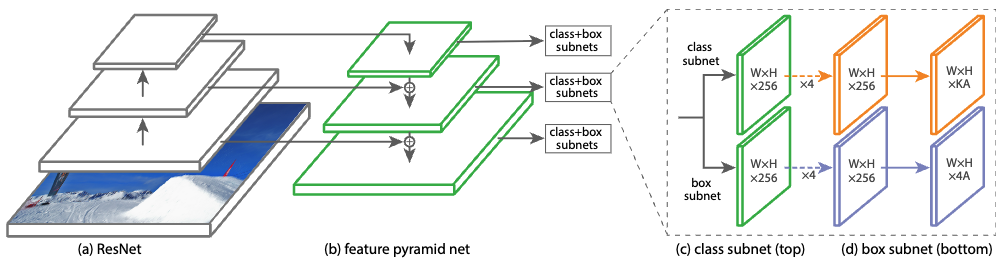

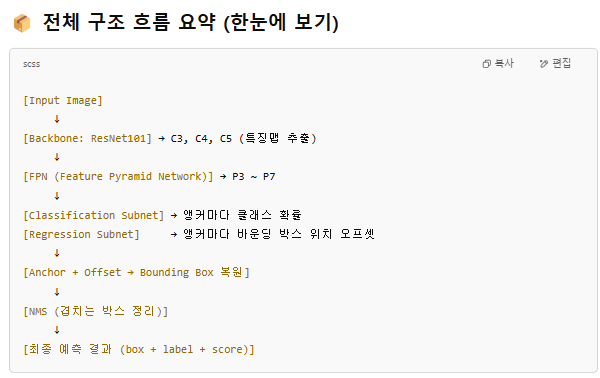

In [11]:
# PyTorch의 모든 딥러닝 모델은 nn.Module을 기반으로 만들어진다!
# 내가 정의한 커스텀 레이어나 모델도 nn.Module을 상속해야 PyTorch에서 학습되고, .cuda(), .eval(), .train() 같은 기능이 작동해


#########################################
# TODO: complete this PyramidFeatures   #
# upsample mode: nearest                #
#########################################
# [START]


class PyramidFeatures(nn.Module):
    def __init__(self, C3_size, C4_size, C5_size, feature_size=256):
        """
        FPN (Feature Pyramid Network) 모듈의 초기화 함수.
        주어진 C3, C4, C5 feature map의 채널 수와 목표 feature map 채널(feature_size)를 사용하여,
        P3, P4, P5, P6, P7을 생성합니다.

        Args:
            C3_size (int): C3 feature map의 채널 수.
            C4_size (int): C4 feature map의 채널 수.
            C5_size (int): C5 feature map의 채널 수.
            feature_size (int): FPN에서 출력할 feature map의 채널 수 (보통 256).
        """
        super(PyramidFeatures, self).__init__()  # 부모(nn.Module)의 초기화 호출

        # -----------------------------
        # P5 생성: C5에서 시작
        # -----------------------------
        # 1x1 컨볼루션을 적용하여 C5의 채널 수를 feature_size로 맞춤.
        self.P5_1 = nn.Conv2d(C5_size, feature_size, kernel_size=1, stride=1, padding=0)
        # P5_1의 출력 feature map을 2배 업샘플링 (Nearest Neighbor 방식 사용)
        self.P5_upsampled = nn.Upsample(scale_factor=2, mode='nearest')
        # 업샘플링 이전의 P5_1 출력을 3x3 컨볼루션으로 보정하여 최종 P5 feature map 생성
        self.P5_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # -----------------------------
        # P4 생성: C4와 P5를 결합
        # -----------------------------
        # C4 feature map에 1x1 컨볼루션을 적용하여 채널 수를 feature_size로 맞춤.
        self.P4_1 = nn.Conv2d(C4_size, feature_size, kernel_size=1, stride=1, padding=0)
        # P5_upsampled를 사용하여 C4와 동일한 해상도로 만든 후, 두 feature map을 element-wise 덧셈
        self.P4_upsampled = nn.Upsample(scale_factor=2, mode='nearest')
        # 합쳐진 P4 feature map을 3x3 컨볼루션으로 보정하여 최종 P4 생성
        self.P4_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # -----------------------------
        # P3 생성: C3와 P4를 결합
        # -----------------------------
        # C3에 1x1 컨볼루션을 적용하여 채널 수 맞춤.
        self.P3_1 = nn.Conv2d(C3_size, feature_size, kernel_size=1, stride=1, padding=0)
        # P3_1과 P4_upsampled (P4에서 업샘플링된 결과)를 element-wise 덧셈하여 결합
        self.P3_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # -----------------------------
        # P6 생성: C5를 바로 다운샘플링
        # -----------------------------
        # C5 feature map에 3x3 컨볼루션을 stride 2로 적용하여, 해상도를 2배 낮춤.
        self.P6 = nn.Conv2d(C5_size, feature_size, kernel_size=3, stride=2, padding=1)

        # -----------------------------
        # P7 생성: P6의 후처리
        # -----------------------------
        # P6에 ReLU 활성화 함수를 적용하여 non-linearity 추가.
        self.P7_1 = nn.ReLU()
        # P7_1의 결과에 3x3 컨볼루션을 stride 2로 적용하여, P7 feature map 생성.
        self.P7_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=2, padding=1)

    def forward(self, inputs):
        """
        백본(ResNet)으로부터 나온 C3, C4, C5 feature map을 입력받아,
        FPN을 통해 P3, P4, P5, P6, P7 feature map을 생성합니다.

        Args:
            inputs (list of Tensor): [C3, C4, C5] feature maps

        Returns:
            List of Tensors: [P3, P4, P5, P6, P7] feature maps.
        """
        # inputs는 리스트로 [C3, C4, C5]가 들어옵니다.
        C3, C4, C5 = inputs

        # -------- P5 계산 --------
        P5_x = self.P5_1(C5)  # C5에 1x1 conv → shape: (B, feature_size, H, W)
        P5_upsampled_x = self.P5_upsampled(P5_x)  # P5_x를 2배 업샘플링 → (B, feature_size, 2H, 2W)
        P5_x = self.P5_2(P5_x)  # P5_x에 3x3 conv로 보정

        # -------- P4 계산 --------
        P4_x = self.P4_1(C4)  # C4에 1x1 conv → (B, feature_size, H', W')
        P4_x = P4_x + P5_upsampled_x  # P5_upsampled_x와 덧셈 (둘 다 같은 해상도)
        P4_upsampled_x = self.P4_upsampled(P4_x)  # P4_x를 2배 업샘플링 → (B, feature_size, 2H', 2W')
        P4_x = self.P4_2(P4_x)  # 3x3 conv로 보정

        # -------- P3 계산 --------
        P3_x = self.P3_1(C3)  # C3에 1x1 conv → (B, feature_size, H'', W'')
        P3_x = P3_x + P4_upsampled_x  # P3_x와 P4_upsampled_x 덧셈 (동일 해상도)
        P3_x = self.P3_2(P3_x)  # 3x3 conv 보정

        # -------- P6 계산 --------
        P6_x = self.P6(C5)  # C5에 3x3 conv stride 2 → (B, feature_size, H/2, W/2)

        # -------- P7 계산 --------
        P7_x = self.P7_1(P6_x)  # ReLU 적용
        P7_x = self.P7_2(P7_x)  # 3x3 conv stride 2 → (B, feature_size, H/4, W/4)

        return [P3_x, P4_x, P5_x, P6_x, P7_x]

# [END]

#########################################
# TODO: complete this RegressionModel   #
#########################################
# [START]


class RegressionModel(nn.Module):
    def __init__(self, num_features_in, num_anchors=9, feature_size=256):
        """
        RegressionModel 클래스는 FPN의 각 피쳐 맵에서
        각 앵커에 대해 bounding box 회귀값 (Δx, Δy, Δw, Δh)을 예측합니다.

        Args:
            num_features_in (int): 입력 feature map의 채널 수.
            num_anchors (int): 한 셀당 anchor의 수 (예: ratios와 scales의 조합으로 보통 9개).
            feature_size (int): 모델 내의 중간 레이어 출력 채널 수 (보통 256).
        """
        super(RegressionModel, self).__init__()  # 부모 클래스(nn.Module) 초기화

        # 첫 번째 3x3 컨볼루션 레이어: 입력 feature map을 feature_size 채널로 변환
        self.conv1 = nn.Conv2d(num_features_in, feature_size, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()  # ReLU 활성화 함수

        # 두 번째 3x3 컨볼루션 레이어: feature_size 채널 유지하며 추가 특징 추출
        self.conv2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()

        # 세 번째 3x3 컨볼루션 레이어: 더 깊은 특징 추출
        self.conv3 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act3 = nn.ReLU()

        # 네 번째 3x3 컨볼루션 레이어: 추가적인 non-linearity 후 마지막 전처리
        self.conv4 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act4 = nn.ReLU()

        # 최종 출력 레이어: 각 anchor에 대해 4개의 값을 예측
        # num_anchors * 4 출력 채널을 가지며, 여기서 4는 (dx, dy, dw, dh)를 의미합니다.
        self.output = nn.Conv2d(feature_size, num_anchors * 4, kernel_size=3, padding=1)

    def forward(self, x):
        """
        입력 feature map x를 받아서, 각 위치별로 회귀 예측값을 출력합니다.

        Args:
            x (Tensor): 입력 feature map, shape (batch_size, num_features_in, H, W)

        Returns:
            Tensor: 회귀 예측 결과, shape (batch_size, N, 4)
                    여기서 N는 전체 anchor 개수 (H * W * num_anchors)
        """
        # 첫 번째 컨볼루션과 활성화
        out = self.conv1(x)   # shape: (B, feature_size, H, W)
        out = self.act1(out)  # 비선형성 추가

        # 두 번째 컨볼루션과 활성화
        out = self.conv2(out)
        out = self.act2(out)

        # 세 번째 컨볼루션과 활성화
        out = self.conv3(out)
        out = self.act3(out)

        # 네 번째 컨볼루션과 활성화
        out = self.conv4(out)
        out = self.act4(out)

        # 최종 출력 레이어 적용, 여기서 각 앵커에 대해 4값을 예측
        out = self.output(out)  # shape: (B, num_anchors*4, H, W)

        # 출력 텐서의 차원 순서를 변경 (batch, H, W, channels)
        out = out.permute(0, 2, 3, 1)
        # contiguously view해서 (B, H*W*num_anchors, 4) 형태로 변환
        out = out.contiguous().view(out.shape[0], -1, 4)

        return out


# [END]

#############################################
# TODO: complete this ClassificationModel   #
#############################################
# [START]

class ClassificationModel(nn.Module):
    def __init__(self, num_features_in, num_anchors=9, num_classes=80, prior=0.01, feature_size=256):
        """
        ClassificationModel은 RetinaNet에서 각 앵커(anchor)에 대해
        물체의 클래스를 예측하는 모델입니다.

        Args:
            num_features_in (int): 입력 feature map의 채널 수.
            num_anchors (int): 한 셀당 생성되는 앵커 수 (보통 9).
            num_classes (int): 예측할 클래스 수.
            prior (float): 초기 bias 설정을 위한 사전 확률.
            feature_size (int): 중간 레이어에서 사용할 채널 수 (보통 256).
        """
        super(ClassificationModel, self).__init__()  # 부모(nn.Module) 초기화

        self.num_classes = num_classes
        self.num_anchors = num_anchors

        # 1. 첫 번째 3x3 합성곱 레이어
        # 입력 feature map을 feature_size 채널로 변환하여 기본 특징을 추출합니다.
        self.conv1 = nn.Conv2d(num_features_in, feature_size, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()  # 활성화 함수 ReLU 적용

        # 2. 두 번째 3x3 합성곱 레이어: 추가적인 특징 추출 (채널 수 유지)
        self.conv2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()

        # 3. 세 번째 3x3 합성곱 레이어
        self.conv3 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act3 = nn.ReLU()

        # 4. 네 번째 3x3 합성곱 레이어
        self.conv4 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act4 = nn.ReLU()

        # 5. 최종 출력 레이어: 각 앵커에 대해 num_classes 개의 값을 예측
        # 출력 채널 수는 num_anchors * num_classes, 여기서 4는 각 앵커 당 예측값이 아니고,
        # 분류 결과로서 각 앵커에 대해 num_classes 개의 확률을 예측합니다.
        self.output = nn.Conv2d(feature_size, num_anchors * num_classes, kernel_size=3, padding=1)
        # Sigmoid 활성화: 각 예측값을 0~1 사이의 확률로 변환합니다.
        self.output_act = nn.Sigmoid()

    def forward(self, x):
        """
        입력 feature map x를 받아서, 각 앵커에 대해 클래스 확률을 예측합니다.

        Args:
            x (Tensor): 입력 feature map, shape (batch_size, num_features_in, H, W)

        Returns:
            Tensor: 예측 결과, shape (batch_size, H*W*num_anchors, num_classes)
        """
        # 1. 첫 번째 합성곱 레이어와 ReLU 적용
        out = self.conv1(x)    # 출력 shape: (B, feature_size, H, W)
        out = self.act1(out)   # 활성화 함수 적용

        # 2. 두 번째 합성곱과 ReLU 적용
        out = self.conv2(out)
        out = self.act2(out)

        # 3. 세 번째 합성곱과 ReLU 적용
        out = self.conv3(out)
        out = self.act3(out)

        # 4. 네 번째 합성곱과 ReLU 적용
        out = self.conv4(out)
        out = self.act4(out)

        # 5. 최종 출력 레이어를 통해 각 앵커에 대한 분류값 예측
        out = self.output(out)      # 출력 shape: (B, num_anchors*num_classes, H, W)
        out = self.output_act(out)  # Sigmoid 적용, 확률 값으로 변환

        # 6. 차원 순서 변경: (B, num_anchors*num_classes, H, W) → (B, H, W, num_anchors*num_classes)
        out = out.permute(0, 2, 3, 1)

        # 7. 출력 채널 수를 (num_anchors, num_classes)로 나누기 위해 shape 변환
        batch_size, H, W, channels = out.shape  # channels = num_anchors * num_classes
        # view()를 사용해 마지막 차원을 두 개의 차원으로 나눔
        out = out.view(batch_size, H, W, self.num_anchors, self.num_classes)

        # 8. (B, H, W, num_anchors, num_classes) → (B, H*W*num_anchors, num_classes)로 reshape
        out = out.contiguous().view(batch_size, -1, self.num_classes)

        return out
# [END]

In [12]:
#########################################
# 모델에 사용할 사전 학습된 ResNet URL들
#########################################
# - model_urls는 파이썬의 딕셔너리(dictionary)를 사용하여
#   ResNet의 다양한 버전별로 사전 학습된 모델 파일의 URL을 저장해요.
# - 딕셔너리: {key: value} 형식, key는 문자열, value는 문자열 URL
model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

#########################################
# 3x3 Convolution 함수
#########################################
# - conv3x3 함수는 입력 채널 수와 출력 채널 수, stride를 받아서 3x3 컨볼루션 레이어를 생성해요.
#stride란 conv필터를 몇칸씩 건너뛰며 적용할것인지 1이면 모든 위치에서 필터적
# - nn.Conv2d: PyTorch의 2D 컨볼루션 클래스

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)
# in_planes : 입력 채널 수 (Input Channels) 즉, RGB 이미지면 보통 3, feature map이 들어올 땐 그 feature의 채널 수
#out_planes : 출력 채널 수 (Output Channels) 즉, 컨볼루션을 통과한 뒤의 feature map이 가질 채널 수
#kernel_size=3 3×3 필터를 사용한다는 뜻





#########################################
# Residual Block (잔차 블록)이란? 딥러닝에서 깊은 네트워크를 안정적으로 학습시키기 위해 사용하는 구조야.
# output = f(x) + x
#########################################
# - BasicBlock은 ResNet에서 사용되는 기본 residual block 구조예요.
# - 잔차 연결(residual connection)을 사용하여 학습이 잘 되도록 도와줌

class BasicBlock(nn.Module):
    # expansion은 블록에서 출력 채널 수를 계산할 때 사용
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        # nn.Module을 상속받은 클래스의 생성자 호출
        super(BasicBlock, self).__init__()

        # 첫번째 3x3 컨볼루션 레이어, stride가 있을 수 있음
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)  # 배치 정규화 (BatchNorm2d)
        self.relu = nn.ReLU(inplace=True)  # 활성화 함수 ReLU
        # 두번째 3x3 컨볼루션 레이어
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        # downsample: 입력과 출력 크기가 다를 때 차원을 맞추기 위한 모듈
        self.downsample = downsample

    def forward(self, x):
        # forward 함수: 모듈이 입력 데이터를 처리하는 방식 정의
        residual = x  # 입력을 나중에 더하기 위해 저장

        out = self.conv1(x)  # 첫 번째 컨볼루션 적용
        out = self.bn1(out)  # 배치 정규화 적용
        out = self.relu(out) # ReLU 활성화 적용

        out = self.conv2(out)  # 두 번째 컨볼루션 적용
        out = self.bn2(out)    # 배치 정규화 적용

        # downsample 모듈이 있으면 residual에 적용하여 크기 맞춤
        if self.downsample is not None:
            residual = self.downsample(x)

        # 잔차 연결: 컨볼루션 결과와 원래 입력을 더함
        out += residual
        out = self.relu(out)  # 마지막으로 ReLU 적용

        return out


#########################################
# Residual Block (Bottleneck)
#########################################
# - Bottleneck 블록은 ResNet에서 깊은 네트워크에 사용되는 구조로,
#   채널 수를 축소했다가 다시 확장하여 연산량을 줄이는 효과가 있어요.
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # 1x1 컨볼루션: 채널 수 축소
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # 3x3 컨볼루션: 실제 공간적 특징 추출
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # 1x1 컨볼루션: 채널 수 확장
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


#############################################
# BBoxTransform 모듈 (TODO)
#############################################
# - BBoxTransform은 회귀 모델의 예측값(Δx, Δy, Δw, Δh)을 이용하여
#   앵커 박스를 실제 bounding box로 변환하는 모듈이에요.
# - 이때 Δx, Δy, Δw, Δh 은 정규화 되어있는데 그걸 mean과 std를 사용해 정규화된 값을 원래 scale로 복원하는
class BBoxTransform(nn.Module):
    def __init__(self, mean=None, std=None):
        super(BBoxTransform, self).__init__()
        #super()는 부모 클래스 (nn.Module)의 생성자를 호출해주는 함수야.
        # PyTorch의 nn.Module은 내부에서 많은 중요한 기능 (예: .parameters(), .cuda(), .train())을 설정함
        # 부모 클래스의 내부 기능이 작동 안 함 → forward()가 안 돌 수도 있고, .cuda()도 안 될 수 있음



# 여기부터 하는일 : 이 코드는 "BBoxTransform"이 예측한 바운딩 박스를 **디코딩할 때 필요한 기준값(mean, std)**을 설정하는 과정이고,
# 사용자가 따로 넘기지 않으면 기본값을 만들어서 GPU에 올려 저장하는 거야.

        if mean is None:
            # 기본 mean 값 설정 (numpy array → torch tensor, float32)
            self.mean = torch.from_numpy(np.array([0, 0, 0, 0]).astype(np.float32)).cuda()
        else:
            self.mean = mean

        if std is None:
            # 기본 std 값 설정
            self.std = torch.from_numpy(np.array([0.1, 0.1, 0.2, 0.2]).astype(np.float32)).cuda()
        else:
            self.std = std
            #.cuda() : gpu메모리에 올리는 코드 모델도 gpu에 올라가있으니 이 변수들도 gpu로 올려야함

    # TODO: forward 메서드를 완성해야 함 foward함수는 nn.Module을 상속받은 class들이 쓸수 있으며 역할은 매직메소드와 완전히 같다.
    # forward(self,anchors, deltas) 형태로 받아,
    # 앵커 박스(boxes)에 회귀 예측값(deltas)를 적용하여
    # 최종 bounding box 좌표를 반환하도록 구현할 예정.

    def forward(self, anchors, normaldeltas):
      """
      앵커 박스(anchors)와 회귀 예측값(normaldeltas)를 받아서,
      각 앵커 박스에 대해 최종 bounding box 좌표를 계산하여 반환합니다.

      Args:
          anchors (Tensor): 앵커 박스, shape (N, 4), 각 박스는 [x1, y1, x2, y2]로 표현됩니다.
          normaldeltas (Tensor): 회귀 모델의 예측값, shape (N, 4), 각 값은 정규화된 [dx, dy, dw, dh]입니다.

      Returns:
          Tensor: 복원된 bounding box 좌표, shape (N, 4)
      """
      # 1. 예측값(normaldeltas)을 복원: 정규화된 값을 mean, std를 사용하여 원래 스케일로 복원합니다.
      #    각 요소에 대해: unnormalized_delta = delta * std + mean
      deltas = (normaldeltas * self.std) + self.mean

      # 2. 각 앵커 박스의 너비와 높이를 계산합니다.
      #    너비 = x2 - x1, 높이 = y2 - y1
      widths  = anchors[:, 2] - anchors[:, 0]
      heights = anchors[:, 3] - anchors[:, 1]

      # 3. 각 앵커 박스의 중심 좌표를 계산합니다.
      ctr_x = (anchors[:, 0] + anchors[:, 2]) / 2
      ctr_y = (anchors[:, 1] + anchors[:, 3]) / 2

      # 4. 복원된 예측값을 이용하여 각 박스의 새로운 중심 좌표를 계산합니다.
      #  정규화한 dx, dy, dw, dh는 비율이라 너비,높이 에 곱하는것
      pred_ctr_x = deltas[:, 0] * widths + ctr_x
      pred_ctr_y = deltas[:, 1] * heights + ctr_y

      # 5. 예측된 폭(width)과 높이(height)는 exp를 사용하여 계산합니다.
      #   예측된 width = exp(dw) * original width, (유사하게 height)
      dw=deltas[:, 2]
      dh=deltas[:, 3]
      pred_w = torch.exp(dw) * widths
      pred_h = torch.exp(dh) * heights

      # 6. 최종 bounding box 좌표를 계산합니다.


      pred_boxes_x1 = pred_ctr_x - 0.5 * pred_w  # x1
      pred_boxes_y1 = pred_ctr_y - 0.5 * pred_h  # y1
      pred_boxes_x2 = pred_ctr_x + 0.5 * pred_w  # x2
      pred_boxes_y2 = pred_ctr_y + 0.5 * pred_h  # y2
      pred_boxes = torch.stack([pred_boxes_x1, pred_boxes_y1, pred_boxes_x2, pred_boxes_y2], dim=1)
      return pred_boxes

#############################################
# ClipBoxes 모듈
#############################################
# - ClipBoxes는 이미지 경계를 벗어나는 박스를 이미지 크기에 맞춰 잘라내는 역할
class ClipBoxes(nn.Module):
    def __init__(self, width=None, height=None):
        super(ClipBoxes, self).__init__()

    def forward(self, boxes, img):
        # img.shape: [batch_size, num_channels, height, width]
        batch_size, num_channels, height, width = img.shape

        # 박스 좌표가 0보다 작지 않도록, 그리고 이미지 크기보다 크지 않도록 clamp 함수 사용
        boxes[:, :, 0] = torch.clamp(boxes[:, :, 0], min=0)
        boxes[:, :, 1] = torch.clamp(boxes[:, :, 1], min=0)
        boxes[:, :, 2] = torch.clamp(boxes[:, :, 2], max=width)
        boxes[:, :, 3] = torch.clamp(boxes[:, :, 3], max=height)

        return boxes

####################################################################################
# Anchor 클래스, generate_anchors 함수, shift 함수 (TODO 부분)
# RetinaNet은 이미지를 훑으면서 "여기에 물체가 있을지도 몰라!" 하는 anchor box들을 미리 뿌려놓고,
# 나중에 이 박스가 진짜 물체일지 아닐지를 학습하면서 결정해.
# 이 anchor box들을 만들고 위치를 옮겨서 전체 이미지에 고르게 뿌리는 게 네 과제야!
####################################################################################
# - Anchors 클래스는 다양한 크기, 비율의 base anchor 박스를 생성하는 역할
# - generate_anchors()는 주어진 base size, ratios, scales를 사용하여
#   기본 anchor들을 생성
# - shift() 함수는 각 feature map의 각 셀의 중심에 맞춰서
#   base anchor들을 이동(shift)시켜줌.
# [START]
class Anchors(nn.Module):
    def __init__(self, pyramid_levels=None, strides=None, sizes=None, ratios=None, scales=None):
        super(Anchors, self).__init__()
        # 기본 설정: pyramid_levels, strides, sizes는 사용자가 지정할 수 있도록 함.
        if pyramid_levels is None:
            # TODO: FPN에서 사용하는 feature pyramid의 각 단계 (P3, P4, P5, P6, P7)
            self.pyramid_levels = [3, 4, 5, 6, 7]

        if strides is None:
            # TODO: strides란 각 피라미드 레벨의 feature map이 원본 이미지에 비해 얼마나 downsample 되어 있는지
            #예: P3은 8배 축소 → stride = 8

            self.strides = [2 ** x for x in self.pyramid_levels] # [8, 16, 32, 64, 128]

        if sizes is None:
            # TODO:sizes란 각 피라미드 레벨에서 사용하는 base anchor의 크기
            # Feature map 해상도가 낮다는 건, 원본 이미지의 더 넓은 영역을 대표한다는 뜻이기 때문에, 큰 anchor를 써야 해.

            self.sizes = [2 ** (x + 2) for x in self.pyramid_levels]

        # ratios와 scales는 기본값을 사용
        if ratios is None:
            self.ratios = np.array([0.5, 1, 2])
        else:
            self.ratios = ratios

        if scales is None:
            self.scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])
        else:
            self.scales = scales


    def forward(self, image):
      #입력 이미지가 주어졌을 때, RetinaNet의 FPN 레벨 (P3 ~ P7)에서
      #각 feature map이 몇 x 몇 크기를 가지는지를 미리 계산하는 거야. 이 크기에 맞춰 anchor box를 만들어야 하니까!

        # image.shape: [batch_size, channels, height, width] 중에 height,width만 꺼내는거 이거가 앵커만들때 중요한 정보니까
        image_shape = image.shape[2:]
        image_shape = np.array(image_shape)



        #중요! 여기서 진짜 anchor 크기를 만드는 핵심 피라미드별 feature map 계산
        #피라미드 레벨에 따라 해상도가 달라짐 x는 피라미드 레벨이고  계산한 결과인 images_shapes가 피라미드별 nxn 크기의 feature map임
        image_shapes = [(image_shape + 2 ** x - 1) // (2 ** x) for x in self.pyramid_levels]



        #0개의 박스를 가진 (N=0, 4) shape의 빈 박스 텐서를 만들어요.즉, 아직 아무 앵커도 없지만 박스 형태 [x1, y1, x2, y2]를 위해 자리를 잡아주는 역할이야.
         # 예시 입력 이미지 크기: 600x800
        # P3 (2^3 = 8배 다운): (600+7)//8 = 75, (800+7)//8 = 100
        # P7 (2^7 = 128배 다운): (600+127)//128 = 5, (800+127)//128 = 7

        all_anchors = torch.zeros((0, 4), dtype=torch.float32)
        #이건 **"아직 아무 anchor도 없지만, shape이 [x1, y1, x2, y2]인 박스를 저장할 공간을 만들어두는 것"
        # 0 → 현재는 아무 anchor도 없다는 뜻 (행이 0개)
        # 4 → anchor 하나당 4개의 숫자를 저장해야 함:
        # [x1, y1, x2, y2]


        # pyramid_levels는 피처 피라미드의 레벨들(P3~P7)을 담은 리스트예요.
        # 예: [3, 4, 5, 6, 7]
        # enumerate()를 쓰면 idx는 인덱스(0부터 시작), p는 해당 레벨 값을 줘요.
        for idx, p in enumerate(self.pyramid_levels):


            # 현재 레벨의 base_size, ratios, scales를 이용해서 base anchor box들을 생성해요.
            # generate_anchors() 함수는 (A, 4) 모양의 텐서를 반환하는데 A는 하나의 셀에서 만들어지는 anchor box 개수예요. (예: 9개)
            anchors = generate_anchors(base_size=self.sizes[idx], ratios=self.ratios, scales=self.scales)


            #base anchor들을 해당 레벨의 feature map 전체 셀에 복사/이동해서 전체 위치에 anchor를 만들어주는 역할이에요
            shifted_anchors = shift(image_shapes[idx], self.strides[idx], anchors)

            #image_shapes[idx]: 현재 레벨의 feature map 크기 (예: 40x40)
            # strides[idx]: 원본 이미지 대비 축소 비율 (예: 2^level)
            # anchors: 하나의 셀 기준 anchor 박스들
            # → 최종적으로 shifted_anchors는 (H×W×A, 4) 모양의 텐서가 돼요.


            #모든 pyramid level에서 만든 anchor 박스들을 하나로 쌓아가는 코드입니다.
            all_anchors = torch.cat((all_anchors, shifted_anchors), dim=0)
            # all_anchors: 누적 결과 (처음에는 빈 텐서 (0, 4)로 시작)
            # shifted_anchors: 방금 생성한 anchor 박스들
            # → torch.cat(..., dim=0)으로 행 방향으로 이어 붙여요.


        # 축을 하나 추가하여 batch 차원과 맞춤
        all_anchors = np.expand_dims(all_anchors, axis=0)

        # 최종적으로 numpy array를 torch tensor로 변환 후 CUDA 메모리로 이동
        return torch.from_numpy(all_anchors.astype(np.float32)).cuda()


# base_size + ratios + scales 를 조합해서 한 위치에서 다양한 크기와 비율의 anchor들을 만듦

# TODO: generate_anchors 함수 정의
def generate_anchors(base_size=16, ratios=None, scales=None):
    # base size, ratios, scales를 이용해서 base anchor들을 생성하는 함수
    #basesize가 16인 이유는 p3의 해상도가 원본의 1/8임
    #그러므로 앵커의 한변사이즈는 8 이어야하는데 그럼 사진이 너무 꼭맞으니 2배로 늘려 16으로한것
    #ratio는 박스의 가로세로 비율
    #scale은 박스의 절대 크기 (면적)

    #비율이 정해지지않았다면 2:1 , 1:1, 1:2 크기의 앵커박스를 만듬
    #ratio = 2이면 h = 2w

    if ratios is None:
        ratios = torch.tensor([0.5, 1.0, 2.0], dtype=torch.float32)

    if scales is None:
        scales = torch.tensor([1.0, 1.3, 1.6], dtype=torch.float32)

     #한 셀에서 생성될 앵커의 갯수 총 9개
    num_anchors = len(ratios) * len(scales)

    #앵커들 담을 텐서 만들기 차원은 2 (앵커들이 행 열이 x1y1x2y2)
    anchors = torch.zeros((num_anchors, 4), dtype=torch.float32)

    # [0, 0, base_size, base_size] (0, 0)부터 (base_size, base_size)까지인 정사각형 만듬
     # 거기서 한변/2만큼 뺴면 중심이 0,0에 갈
    base_anchor = torch.tensor([0, 0, base_size, base_size], dtype=torch.float32) - base_size / 2

    x_ctr = (base_anchor[0] + base_anchor[2]) / 2
    y_ctr = (base_anchor[1] + base_anchor[3]) / 2


    index = 0
     #모든 비율에 대해 모든 scale의 앵커를 만들거라 이중 포문
    for ratio in ratios:
      for scale in scales:
        # 기준 앵커의 넓이는 위에서 설정한 한변의 길이 X 한변의 길이
        area = torch.tensor(base_size ** 2, dtype=torch.float32)

        # h = w×ratio
        # area = w×h
        # 즉 area = w x w x ratio
        w = torch.sqrt(area / ratio) * scale
        h = w * ratio


        anchors[index, 0] = x_ctr - w / 2  # x1
        anchors[index, 1] = y_ctr - h / 2  # y1
        anchors[index, 2] = x_ctr + w / 2  # x2
        anchors[index, 3] = y_ctr + h / 2  # y2
        index += 1

    return anchors





# TODO: shift 함수 정의
def shift(image_shapes, stride, anchors):
    """
    위에까지는 "한 위치(0,0)에 정렬된 기준 anchor들" → 즉, 한 셀의 중심에만 박스가 있어. 근데 우리는 모든 셀의 중앙에 앵커를 놓고싶어

    예를 들어 feature map의 크기가 4x4라면:총 16개의 위치(셀 중심)가 있지?
    각 위치마다 9개의 anchor를 배치해야 해 (3 ratios × 3 scales) 16 × 9 = 144개의 anchor 박스가 필요!
    → 이걸 수동으로 반복하면서 박스를 옮기지 않고, shift() 함수가 모든 좌표에 anchor들을 자동으로 "복사 + 이동" 해주는 거야.

    Args:
        image_shapes: feature map의 높이와 너비 (H, W)
        stride: 원본 이미지 대비 축소 비율 (ex: 8이면 1/8)
        anchors: 기준 anchor들, shape (A, 4)

    Returns:
        모든 위치에 생성된 anchor box들, shape (H*W*A, 4)
    """

    height, width = image_shapes  # 예: (4, 4)
    #여기서의 height , width는 feature map의 너비, 높이

    # torch.arange: 시작~끝 범위의 값을 일정 간격으로 생성하는 함수
    shifts_x = torch.arange(0, width * stride, step=stride, dtype=torch.float32)
    shifts_y = torch.arange(0, height * stride, step=stride, dtype=torch.float32)
    # 너비가 현재 feature map이 너비이고 stride가 원본에 비해 몇배 줄었으니 라는 변수이니 둘을 곱하면 원래 사진의 좌표가 나옴
    #예시) p4 -> 너비 4 , stride =16 즉 p4는 4x4 원본은 64x64 이때 width x stride 는 64 그걸 16칸씩 arrange하니
    #결과값은 shifted_x == [0,16,32,48] feature map에선 [0,1,2,3] 이었을

    # meshgrid: 모든 x, y 조합 생성
    #이 파이토치 함수는 솔직히 첨보기도 하고 지피티 써서 함수 물어봄 ㅇㅇ 이거까지 공부해서 하라는거냐 지금 나보고 시발 어이가없네 ㅋㅋㅋ
    shift_y, shift_x = torch.meshgrid(shifts_y, shifts_x, indexing="ij")
    # shape: (H, W)

    # x, y 각각 2D → 1D로 flatten
    shift_x_flat = shift_x.reshape(-1)
    shift_y_flat = shift_y.reshape(-1)

    # 각각을 1D 텐서로 복사해서 4개 준비
    shift_x1 = shift_x_flat
    shift_y1 = shift_y_flat
    shift_x2 = shift_x_flat
    shift_y2 = shift_y_flat

    # stack으로 한 줄씩 묶기 (x1, y1, x2, y2)
    shifts = torch.stack((shift_x1, shift_y1, shift_x2, shift_y2), dim=1)


    A = anchors.shape[0]  # 한 셀에서 사용할 anchor 수
    K = shifts.shape[0]   # feature map 전체 셀 수

    # 각 anchor를 각 셀 위치로 이동
    shifted_anchors = anchors.view(1, A, 4) + shifts.view(K, 1, 4)
    # .view(1, A, 4) → 첫 차원을 1로 추가해서 **(1, A, 4)**로 만듦. 왜? → 브로드캐스팅을 하기 위해서야!
    # 핵심: 브로드캐스팅!PyTorch는 크기가 맞지 않아도 자동으로 복제해서 연산 가능해.
    #위 연산의 shape 는 (1, A, 4)  +  (K, 1, 4)  →  (K, A, 4)

    return shifted_anchors.reshape(-1, 4)  # (K×A, 4)
    #(K, A, 4) → (K*A, 4)로 펼쳐서 2D 텐서로 반환
    # 즉, 최종적으로 K * A 개의 anchor box가 생성된 거야!

# [END]

#############################################
# ResNet 모델 클래스 (Backbone + FPN 등)
#############################################
# - ResNet 클래스는 기본 CNN(ResNet) 백본을 정의하고,
#   FPN, Regression, Classification, Anchor 생성 등 RetinaNet 전체 구조를 조합
class ResNet(nn.Module):
    def __init__(self, num_classes, block, layers):
        # inplanes: 입력 채널 수, 초기값 64
        self.inplanes = 64
        super(ResNet, self).__init__()
        # 초기 Convolution: 커널 7x7, stride 2, 패딩 3 → 이미지 크기 절반으로 축소
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        # 최대 풀링: 3x3, stride 2, 패딩 1 → 추가적인 크기 축소
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Residual Block들을 여러 층으로 구성
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # FPN을 위한 feature map의 채널 수 결정 (layer2, layer3, layer4의 출력 채널 수 사용)
        if block == BasicBlock:
            fpn_sizes = [self.layer2[layers[1] - 1].conv2.out_channels,
                         self.layer3[layers[2] - 1].conv2.out_channels,
                         self.layer4[layers[3] - 1].conv2.out_channels]
        elif block == Bottleneck:
            fpn_sizes = [self.layer2[layers[1] - 1].conv3.out_channels,
                         self.layer3[layers[2] - 1].conv3.out_channels,
                         self.layer4[layers[3] - 1].conv3.out_channels]
        else:
            raise ValueError(f"Block type {block} not understood")


        #TODO 지금까지 만들어둔거 여기서 다쓰기
        ####################################################################################
        # [START]
        self.fpn = PyramidFeatures(fpn_sizes[0], fpn_sizes[1], fpn_sizes[2])  # FPN 모듈 초기화 C3, C4, C5의 출력 채널 수를 인자로 넘겨줌.
        self.regressionModel = RegressionModel(256)  # 각 앵커에 대해 regression을 수행하는 모델 256은 feature map의 채널 수.
        self.classificationModel =  ClassificationModel(256, num_classes=num_classes)  # 각 앵커에 대해 분류를 수행하는 모델
        self.anchors = Anchors() # 앵커 박스 생성 모듈
        self.regressBoxes = BBoxTransform()  # 회귀 결과를 이용해 박스를 변환하는 모듈 (BBoxTransform)
        # [END]

        self.clipBoxes = ClipBoxes()

        self.lossModule = None  # 학습 시에 사용할 손실 함수 모듈

        # 모든 모듈의 파라미터 초기화 (컨볼루션, 배치 정규화 등)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                # 정규분포를 사용하여 가중치 초기화
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

        # 모델의 초기화 설정: 분류 모델의 bias 초기화 (prior probability)
        prior = 0.01
        self.classificationModel.output.weight.data.fill_(0)
        self.classificationModel.output.bias.data.fill_(-math.log((1.0 - prior) / prior))
        self.regressionModel.output.weight.data.fill_(0)
        self.regressionModel.output.bias.data.fill_(0)

        # 배치 정규화 층 freeze: 학습 도중에는 고정 (추가 fine-tuning을 위해)
        self.freeze_bn()

    # _make_layer: Residual Block 여러 개를 쌓아서 하나의 층을 구성하는 함수
    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        # 입력과 출력의 크기가 다르면 downsample을 통해 차원 맞춤
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        # blocks는 해당 층에 쌓을 block의 개수를 의미
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        # nn.Sequential: 여러 모듈을 순차적으로 연결하는 컨테이너
        return nn.Sequential(*layers)

    # freeze_bn: 모든 BatchNorm 레이어를 eval 모드로 설정하여 파라미터 업데이트를 막음
    def freeze_bn(self):
        '''Freeze BatchNorm layers.'''
        for layer in self.modules():
            if isinstance(layer, nn.BatchNorm2d):
                layer.eval()

    def forward(self, inputs):
        # forward 함수: 모델이 입력을 받아 처리하는 전체 과정을 정의함.
        if self.training:
            img_batch, annotations = inputs  # 학습 시에는 이미지와 정답(annotation)을 받음
        else:
            img_batch = inputs

        # 초기 Conv, BatchNorm, ReLU, MaxPool를 통해 특징 추출
        x = self.conv1(img_batch)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Block을 통과하면서 점차 깊은 특징 추출
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # FPN 모듈에 layer2, layer3, layer4의 출력을 전달하여 피라미드 피쳐맵 생성
        features = self.fpn([x2, x3, x4])

        # 각 피쳐맵에 대해 regression 모델 적용 후 결과를 concatenate
        regression = torch.cat([self.regressionModel(feature) for feature in features], dim=1)
        # 각 피쳐맵에 대해 classification 모델 적용 후 결과를 concatenate
        classification = torch.cat([self.classificationModel(feature) for feature in features], dim=1)

        # 앵커 박스 생성: 이미지에 맞춰서 anchor 박스들을 생성
        anchors = self.anchors(img_batch)

        if self.training:
            # 학습 시에는 손실 함수를 통해 loss 계산
            return self.lossModule(classification, regression, anchors, annotations)
        else:
            # 추론 시에는 regression 결과를 사용해 최종 박스 복원 후 NMS 등 후처리 적용
            transformed_anchors = self.regressBoxes(anchors, regression)
            transformed_anchors = self.clipBoxes(transformed_anchors, img_batch)

            finalResult = [[], [], []]

            finalScores = torch.Tensor([])
            finalAnchorBoxesIndexes = torch.Tensor([]).long()
            finalAnchorBoxesCoordinates = torch.Tensor([])

            # CUDA 디바이스로 이동
            finalScores = finalScores.cuda()
            finalAnchorBoxesIndexes = finalAnchorBoxesIndexes.cuda()
            finalAnchorBoxesCoordinates = finalAnchorBoxesCoordinates.cuda()

            # 각 클래스에 대해 처리 (classification.shape[2]는 클래스 수)
            for i in range(classification.shape[2]):
                scores = torch.squeeze(classification[:, :, i])
                scores_over_thresh = (scores > 0.05)
                if scores_over_thresh.sum() == 0:
                    # NMS 적용할 박스가 없으면 continue
                    continue

                scores = scores[scores_over_thresh]
                anchorBoxes = torch.squeeze(transformed_anchors)
                anchorBoxes = anchorBoxes[scores_over_thresh]
                anchors_nms_idx = nms(anchorBoxes, scores, 0.5)

                finalResult[0].extend(scores[anchors_nms_idx])
                finalResult[1].extend(torch.tensor([i] * anchors_nms_idx.shape[0]))
                finalResult[2].extend(anchorBoxes[anchors_nms_idx])

                finalScores = torch.cat((finalScores, scores[anchors_nms_idx]))
                finalAnchorBoxesIndexesValue = torch.tensor([i] * anchors_nms_idx.shape[0])
                finalAnchorBoxesIndexesValue = finalAnchorBoxesIndexesValue.cuda()

                finalAnchorBoxesIndexes = torch.cat((finalAnchorBoxesIndexes, finalAnchorBoxesIndexesValue))
                finalAnchorBoxesCoordinates = torch.cat((finalAnchorBoxesCoordinates, anchorBoxes[anchors_nms_idx]))

            return [finalScores, finalAnchorBoxesIndexes, finalAnchorBoxesCoordinates]

# * 여기서 nms()는 Non-Maximum Suppression 함수로, 중복되는 박스를 제거하기 위해 사용

#############################################
# resnet101 생성 함수
#############################################
# - resnet101 함수는 ResNet-101 기반의 RetinaNet 모델을 생성하는 함수
# - pretrained 인자가 True이면, 사전 학습된 가중치를 로드함
def resnet101(num_classes, pretrained=False, **kwargs):
    """Constructs a ResNet-101 model.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    # Bottleneck 블록과 [3, 4, 23, 3] 레이어 구성을 사용하여 ResNet-101 모델 생성
    model = ResNet(num_classes, Bottleneck, [3, 4, 23, 3], **kwargs)
    if pretrained:
        # torch.utils.model_zoo.load_url을 사용하여 URL에서 가중치 로드
        model.load_state_dict(model_zoo.load_url(model_urls['resnet101'], model_dir='.'), strict=False)
    return model


In [13]:
retinanet = resnet101(num_classes=dataset_train.num_classes(), pretrained=True)
retinanet = retinanet.cuda()

Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to ./resnet101-5d3b4d8f.pth
100%|██████████| 170M/170M [00:00<00:00, 238MB/s]


In [14]:
optimizer = optim.Adam(retinanet.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Train: BCE Loss
---
Implement the training step


In [15]:
def calc_iou(a, b):
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])

    iw = torch.min(torch.unsqueeze(a[:, 2], dim=1), b[:, 2]) - torch.max(torch.unsqueeze(a[:, 0], 1), b[:, 0])
    ih = torch.min(torch.unsqueeze(a[:, 3], dim=1), b[:, 3]) - torch.max(torch.unsqueeze(a[:, 1], 1), b[:, 1])

    iw = torch.clamp(iw, min=0)
    ih = torch.clamp(ih, min=0)

    ua = torch.unsqueeze((a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]), dim=1) + area - iw * ih

    ua = torch.clamp(ua, min=1e-8)

    intersection = iw * ih

    IoU = intersection / ua

    return IoU

class BinaryCrossEntropyLoss(nn.Module):
    def forward(self, classifications, regressions, anchors, annotations):
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths  = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x   = anchor[:, 0] + 0.5 * anchor_widths
        anchor_ctr_y   = anchor[:, 1] + 0.5 * anchor_heights

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            if bbox_annotation.shape[0] == 0:
                bce = -(torch.log(1.0 - classification))
                cls_loss = bce
                classification_losses.append(cls_loss.sum())
                regression_losses.append(torch.tensor(0).float().cuda())
                continue

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4]) # num_anchors x num_annotations

            IoU_max, IoU_argmax = torch.max(IoU, dim=1) # num_anchors x 1

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1
            targets = targets.cuda()

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)
            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            cls_loss = bce
            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, torch.zeros(cls_loss.shape).cuda())
            classification_losses.append(cls_loss.sum()/torch.clamp(num_positive_anchors.float(), min=1.0))

            # compute the loss for regression
            if positive_indices.sum() > 0:
                assigned_annotations = assigned_annotations[positive_indices, :]

                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                gt_widths  = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x   = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y   = assigned_annotations[:, 1] + 0.5 * gt_heights

                # clip widths to 1
                gt_widths  = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t()

                targets = targets/torch.Tensor([[0.1, 0.1, 0.2, 0.2]]).cuda()

                regression_diff = torch.abs(targets - regression[positive_indices, :])

                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0
                )
                regression_losses.append(regression_loss.mean())
            else:
                regression_losses.append(torch.tensor(0).float().cuda())

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0, keepdim=True)

In [16]:
retinanet.lossModule = BinaryCrossEntropyLoss()  # 분류 및 회귀 손실 모듈 할당
retinanet.train()                                # 모델을 학습 모드로 전환 (Dropout, BatchNorm 동작 변경)
retinanet.freeze_bn()                            # BatchNorm 레이어를 고정시킴 (학습 중 변화 방지)

print('Num training images: {}'.format(len(dataset_train)))

for epoch_num in range(20):
    retinanet.train()        # 매 epoch마다 학습 모드로 전환
    retinanet.freeze_bn()    # 매 epoch마다 BatchNorm 고정
    epoch_loss = []          # 각 epoch의 손실 값을 저장할 리스트

    for iter_num, data in enumerate(dataloader_train):
        # [START]
        # 1. 옵티마이저의 기울기(gradient) 초기화
        optimizer.zero_grad()  # 이전 배치에서 계산된 기울기를 0으로 초기화

        # 2. 데이터 준비
        # 여기서는 dataloader가 dictionary 형태의 데이터를 반환한다고 가정 (예: {'img': ..., 'annot': ...})
        images = data['img'].cuda()  # 이미지를 retinanet가 위치한 디바이스(GPU)로 이동
        annotations = data['annot'].cuda() # 정답(annotation)도 GPU로 이동

        # 3. 순전파(forward pass)
        # RetinaNet은 학습 시 (이미지, annotation) 튜플을 입력받아 손실(loss)을 반환하도록 설계되어 있음
        classification_loss, regression_loss = retinanet((images, annotations))
        # loss_cls: 분류 손실, loss_reg: 회귀 손실

        # 4. 전체 손실 계산 (분류 + 회귀 손실)
        total_loss = classification_loss+ regression_loss

        # 5. 역전파(backward pass)
        total_loss.backward()  # 미분값(gradient) 계산

        # 6. 파라미터 업데이트

        optimizer.step()
        # 7. 현재 iteration의 손실값을 리스트에 저장 (학습 진행 모니터링용)
        epoch_loss.append(float(total_loss))

        # 8. 진행 상황 출력
        print('Epoch: {} | Iteration: {} | Classification loss: {:1.5f} | Regression loss: {:1.5f}'.format(epoch_num, iter_num, float(classification_loss), float(regression_loss)))

        del classification_loss
        del regression_loss
        # [END]


    #한 epoch의 평균 손실값으로 learning rate scheduler 업데이트
    scheduler.step(np.mean(epoch_loss))

# 학습 완료 후, 모델을 평가 모드로 전환하고 저장
retinanet.eval()
torch.save(retinanet, 'model_final_BCE.pt')

Num training images: 5011


<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)
<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)
<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)


Epoch: 0 | Iteration: 0 | Classification loss: 392.02359 | Regression loss: 1.05449
Epoch: 0 | Iteration: 1 | Classification loss: 268.54218 | Regression loss: 1.07924
Epoch: 0 | Iteration: 2 | Classification loss: 391.43948 | Regression loss: 1.07140


<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)


Epoch: 0 | Iteration: 3 | Classification loss: 315.82645 | Regression loss: 1.03397
Epoch: 0 | Iteration: 4 | Classification loss: 272.61002 | Regression loss: 1.08648
Epoch: 0 | Iteration: 5 | Classification loss: 61.02985 | Regression loss: 1.05371
Epoch: 0 | Iteration: 6 | Classification loss: 302.84958 | Regression loss: 1.04840
Epoch: 0 | Iteration: 7 | Classification loss: 173.91797 | Regression loss: 0.97165
Epoch: 0 | Iteration: 8 | Classification loss: 54.07826 | Regression loss: 1.09247
Epoch: 0 | Iteration: 9 | Classification loss: 110.81024 | Regression loss: 0.93998
Epoch: 0 | Iteration: 10 | Classification loss: 91.09366 | Regression loss: 0.99516
Epoch: 0 | Iteration: 11 | Classification loss: 21.95053 | Regression loss: 1.08893
Epoch: 0 | Iteration: 12 | Classification loss: 23.85974 | Regression loss: 1.14263
Epoch: 0 | Iteration: 13 | Classification loss: 16.84244 | Regression loss: 1.25421
Epoch: 0 | Iteration: 14 | Classification loss: 11.61423 | Regression loss: 1.

KeyboardInterrupt: 

## Load trained RetinaNet and perform inference
---
Let's compare the ground truth and the model's predictions.

In [ ]:
retinanet = torch.load('model_final_BCE.pt', weights_only=False, map_location='cpu')
retinanet = retinanet.cuda()
retinanet.eval()

##### Ground truth

<class 'torch.Tensor'>


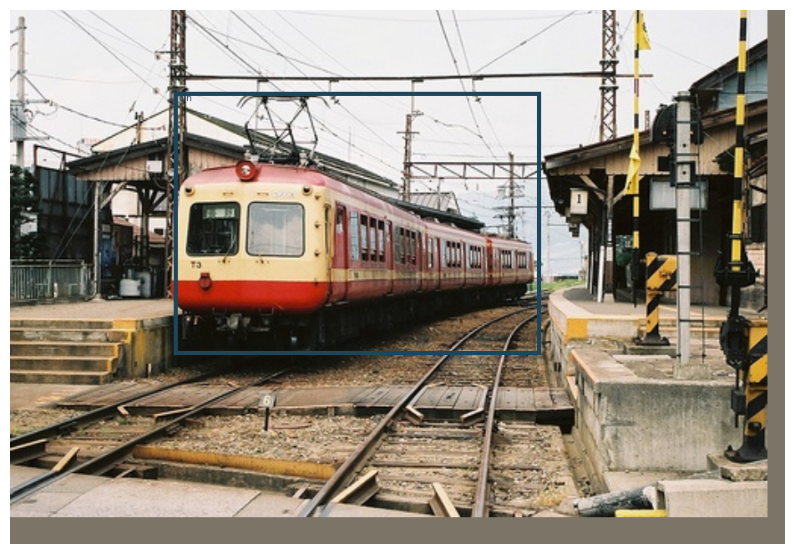

In [23]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=True)

##### Prediction

In [24]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=False, model=retinanet)

<class 'torch.Tensor'>


NameError: name 'retinanet' is not defined

## Focal loss
---
Let's use Focal Loss instead of BCE Loss.    

In object detection, the background is much more prevalent than the objects, which makes the background an easier target to predict. [Focal loss](https://arxiv.org/pdf/1708.02002) was proposed to address this issue by, compared to BCE loss, assigning a smaller loss to well-classified targets (background) and a larger loss to hard-to-classify samples (objects), thereby mitigating the imbalance problem.

In [25]:
class FocalLoss(nn.Module):
    def forward(self, classifications, regressions, anchors, annotations):
        alpha = 0.25
        gamma = 2.0
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths  = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x   = anchor[:, 0] + 0.5 * anchor_widths
        anchor_ctr_y   = anchor[:, 1] + 0.5 * anchor_heights

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            if bbox_annotation.shape[0] == 0:
                alpha_factor = torch.ones(classification.shape).cuda() * alpha

                alpha_factor = 1. - alpha_factor
                focal_weight = classification
                focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

                bce = -(torch.log(1.0 - classification))

                cls_loss = focal_weight * bce
                classification_losses.append(cls_loss.sum())
                regression_losses.append(torch.tensor(0).float().cuda())
                continue

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4]) # num_anchors x num_annotations

            IoU_max, IoU_argmax = torch.max(IoU, dim=1) # num_anchors x 1

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1
            targets = targets.cuda()

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)
            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1

            alpha_factor = torch.ones(targets.shape).cuda() * alpha
            alpha_factor = torch.where(torch.eq(targets, 1.), alpha_factor, 1. - alpha_factor)

            focal_weight = torch.where(torch.eq(targets, 1.), 1. - classification, classification)
            focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            cls_loss = focal_weight * bce
            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, torch.zeros(cls_loss.shape).cuda())
            classification_losses.append(cls_loss.sum()/torch.clamp(num_positive_anchors.float(), min=1.0))

            # compute the loss for regression
            if positive_indices.sum() > 0:
                assigned_annotations = assigned_annotations[positive_indices, :]

                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                gt_widths  = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x   = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y   = assigned_annotations[:, 1] + 0.5 * gt_heights

                # clip widths to 1
                gt_widths  = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t()

                targets = targets/torch.Tensor([[0.1, 0.1, 0.2, 0.2]]).cuda()

                regression_diff = torch.abs(targets - regression[positive_indices, :])

                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0
                )
                regression_losses.append(regression_loss.mean())
            else:
                regression_losses.append(torch.tensor(0).float().cuda())

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0, keepdim=True)

In [26]:
try:
    del retinanet
except:
    pass

torch.cuda.empty_cache()

In [27]:
retinanet_FL = resnet101(num_classes=dataset_train.num_classes(), pretrained=True)
retinanet_FL = retinanet_FL.cuda()

optimizer = optim.Adam(retinanet_FL.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)

In [ ]:
retinanet_FL.lossModule = FocalLoss()
retinanet_FL.train()
retinanet_FL.freeze_bn()

print('Num training images: {}'.format(len(dataset_train)))

for epoch_num in range(20):
    retinanet_FL.train()
    retinanet_FL.freeze_bn()
    epoch_loss = []

    for iter_num, data in enumerate(dataloader_train):
        #############################################
        # TODO: complete following training steps   #
        #############################################
        # [START]

         # 1. 옵티마이저의 기울기를 0으로 초기화합니다.
        optimizer.zero_grad()
        # - optimizer.zero_grad()는 이전 배치에서 계산된 모든 기울기를 0으로 만들어,
        #   현재 배치의 계산이 이전 기울기에 영향을 받지 않도록 합니다.

        # 2. 데이터 준비: DataLoader가 dictionary 형태로 데이터를 반환하므로,
        #    'img'와 'annot' 키를 사용하여 이미지를 annotations를 추출하고 GPU로 이동시킵니다.
        images = data['img'].cuda()         # .cuda()를 사용해 텐서를 GPU로 이동
        annotations = data['annot'].cuda()   # GPU 연산을 위해 모든 데이터를 CUDA 장치로 옮깁니다.

        # 3. 순전파(forward pass): 모델에 (images, annotations) 튜플을 넣어,
        #    분류 손실과 회귀 손실을 계산합니다.
        classification_loss, regression_loss = retinanet_FL((images, annotations))
        # - 여기서 retinanet_FL의 forward 함수는 (images, annotations)를 입력받아
        #   각 앵커(anchor)에 대한 분류 손실과 회귀 손실을 반환합니다.

        # 4. 전체 손실 계산: 분류 손실과 회귀 손실을 합쳐 총 손실을 구합니다.
        loss = classification_loss + regression_loss
        # - 총 손실(loss)은 이 두 손실의 합으로, 모델의 업데이트에 사용됩니다.

        # 5. 역전파(backward pass): 총 손실에 대해 미분을 계산합니다.
        loss.backward()
        # - loss.backward()는 네트워크의 모든 학습 가능한 파라미터에 대해 기울기(gradient)를 계산합니다.

        # 6. 파라미터 업데이트: 옵티마이저를 통해 계산된 기울기를 사용하여 파라미터를 업데이트합니다.
        optimizer.step()
        # - optimizer.step()은 이전 단계에서 계산된 기울기를 바탕으로 파라미터를 업데이트하여
        #   모델이 손실을 줄이도록 학습합니다.

        # 7. 현재 iteration의 총 손실값을 epoch_loss 리스트에 저장하여, 학습 진행 상황을 모니터링합니다.
        epoch_loss.append(float(loss))
        # - float(loss)를 사용하여 텐서 값을 파이썬의 float 타입으로 변환 후 저장합니다.

        # 8. 현재 iteration의 분류 및 회귀 손실을 출력하여 진행 상황을 확인합니다.
        print('Epoch: {} | Iteration: {} | Classification loss: {:1.5f} | Regression loss: {:1.5f}'.format(
            epoch_num, iter_num, float(classification_loss), float(regression_loss)
        ))
        # - format() 함수를 사용하여 각 손실 값을 소수점 5자리까지 출력합니다.

        # 9. (옵션) 메모리 관리를 위해, 사용한 손실 변수들을 삭제합니다.
        del classification_loss
        del regression_loss
        # [END]

    scheduler.step(np.mean(epoch_loss))

retinanet_FL.eval()
torch.save(retinanet_FL, 'model_final_FL.pt')

Num training images: 5011


<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)
<ipython-input-3-a71c8160137d>:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annots = torch.tensor(annots, dtype=torch.float32)


Epoch: 0 | Iteration: 0 | Classification loss: 1.20389 | Regression loss: 1.07172
Epoch: 0 | Iteration: 1 | Classification loss: 1.16772 | Regression loss: 1.13468
Epoch: 0 | Iteration: 2 | Classification loss: 1.18311 | Regression loss: 0.95259
Epoch: 0 | Iteration: 3 | Classification loss: 1.18420 | Regression loss: 1.01348
Epoch: 0 | Iteration: 4 | Classification loss: 1.22476 | Regression loss: 0.58163
Epoch: 0 | Iteration: 5 | Classification loss: 1.14929 | Regression loss: 1.03288
Epoch: 0 | Iteration: 6 | Classification loss: 1.17137 | Regression loss: 1.04872
Epoch: 0 | Iteration: 7 | Classification loss: 1.15719 | Regression loss: 1.06401
Epoch: 0 | Iteration: 8 | Classification loss: 1.14790 | Regression loss: 1.07254
Epoch: 0 | Iteration: 9 | Classification loss: 1.16216 | Regression loss: 1.03853
Epoch: 0 | Iteration: 10 | Classification loss: 1.16314 | Regression loss: 0.99497
Epoch: 0 | Iteration: 11 | Classification loss: 1.14750 | Regression loss: 1.07024
Epoch: 0 | Ite

## Load trained RetinaNet and perform inference
---
Let's compare the ground truth and the model's predictions.

In [ ]:
retinanet_FL = torch.load('model_final_FL.pt', weights_only=False, map_location='cpu')
retinanet_FL = retinanet_FL.cuda()
retinanet_FL.eval()

##### Ground truth

In [ ]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=True)

##### Prediction

In [ ]:
sample = dataset_val[123]
print(type(sample['img']))
show_sample(sample=sample, GT=False, model=retinanet_FL)